In [15]:
# import necessary libraries
import pandas as pd 
import datetime
from zipfile import ZipFile
import glob
import zipfile
import os
import pyarrow as pa
import pyarrow.parquet as pq
import shutil
import requests
import datetime
from datetime import timedelta

In [16]:
# function for latest date
def latest_date(file_list):
    date_list = []
    for file_name in file_list:
        date_ = datetime.datetime.strptime(file_name.split('_')[6], '%Y%m%d').date()
        date_list.append(date_)

    max_date = max(date_list)
    return max_date

list_files = [file[10:] for file in glob.glob('zip_files/*.zip')]
start_date = latest_date(list_files) + datetime.timedelta(1)
end_date = datetime.datetime.now().date()

df = pd.read_excel('./nse_data_url_temp.xlsx')
date_format = "%Y%m%d"

# Function to generate URL based on the date
def generate_url(current_date,type = ""):
  if type=='bhavcopy':
    url = f"https://nsearchives.nseindia.com/content/cm/BhavCopy_NSE_CM_0_0_0_{current_date}_F_0000.csv.zip"
  else:
    url = f"https://nsearchives.nseindia.com/archives/equities/mkt/MA{current_date}.csv"
  return url



# Function to generate URLs from start date till today, excluding weekends
def dates_till_now(current_date,df,today=datetime.datetime.now().date()):
    urls = []
    # Loop through the dates from start date to today
    isUpdate = False
    while current_date <= today:
        # Exclude weekends (Saturday and Sunday)
        if current_date.weekday() != 5 and current_date.weekday() != 6:
            # Generate URL
            urlForBhav = generate_url(current_date.strftime(date_format),"bhavcopy")
            urlForMkt =  generate_url(current_date.strftime("%d%m%y"))
            print(urlForBhav)
            print(urlForMkt)
          

            new_row_df = pd.DataFrame([{
               "BhavCopy": urlForBhav,"MarketReport":urlForMkt,"date":current_date
            }])


            df = pd.concat([df, new_row_df], ignore_index=True)
            isUpdate = True
            
            
            # Append URL to the list
            urls.append({"BhavCopy": urlForBhav,"MarketReport":urlForMkt,"date":current_date})
        # Move to the next day
        current_date += timedelta(days=1)
    if isUpdate:
      df.to_excel('./nse_data_url_temp.xlsx', index=False)
      
dates_till_now(start_date,df,end_date)



https://nsearchives.nseindia.com/content/cm/BhavCopy_NSE_CM_0_0_0_20240809_F_0000.csv.zip
https://nsearchives.nseindia.com/archives/equities/mkt/MA090824.csv
https://nsearchives.nseindia.com/content/cm/BhavCopy_NSE_CM_0_0_0_20240812_F_0000.csv.zip
https://nsearchives.nseindia.com/archives/equities/mkt/MA120824.csv
https://nsearchives.nseindia.com/content/cm/BhavCopy_NSE_CM_0_0_0_20240813_F_0000.csv.zip
https://nsearchives.nseindia.com/archives/equities/mkt/MA130824.csv
https://nsearchives.nseindia.com/content/cm/BhavCopy_NSE_CM_0_0_0_20240814_F_0000.csv.zip
https://nsearchives.nseindia.com/archives/equities/mkt/MA140824.csv
https://nsearchives.nseindia.com/content/cm/BhavCopy_NSE_CM_0_0_0_20240815_F_0000.csv.zip
https://nsearchives.nseindia.com/archives/equities/mkt/MA150824.csv
https://nsearchives.nseindia.com/content/cm/BhavCopy_NSE_CM_0_0_0_20240816_F_0000.csv.zip
https://nsearchives.nseindia.com/archives/equities/mkt/MA160824.csv
https://nsearchives.nseindia.com/content/cm/BhavCopy

In [17]:


def moveFiles(base_dir,target_dir):
    for filename in os.listdir(base_dir):
        basePath = os.path.join(base_dir,filename)
        targetPath = os.path.join(target_dir,filename)
        shutil.move(basePath,targetPath)

def extract_all_zips(directory):
    """
    Extract all zip files in the specified directory.
    
    Parameters:
    directory (str): The path to the directory containing zip files.
    """
    # Ensure the directory exists
    if not os.path.isdir(directory):
        print(f"The directory {directory} does not exist.")
        return

    # Iterate over all files in the directory
    for filename in os.listdir(directory):
        if filename.endswith(".zip"):
            zip_path = os.path.join(directory, filename)
            extract_path = os.path.join(directory, os.path.splitext(filename)[0])
            finalPath =  os.path.join(directory, os.path.splitext(filename)[0],os.path.splitext(filename)[0])

            # Create a directory for the extracted files
            if not os.path.exists(extract_path):
                os.makedirs(extract_path)

            # Extract the zip file
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(extract_path)
                print(f"Extracted {filename} to {extract_path}")



            # Define file paths
            existing_parquet_file = './NSE-Data-2024.parquet'

            # Read the existing Parquet file
            existing_df = pd.read_parquet(existing_parquet_file)

            # Read new records from a CSV file
            new_df = pd.read_csv(finalPath)

            # Concatenate existing DataFrame with new DataFrame
            updated_df = pd.concat([existing_df, new_df], ignore_index=True)

            # Convert the updated DataFrame to a PyArrow Table
            table = pa.Table.from_pandas(updated_df)

            # Write the table to the Parquet file (overwrite or append)
            pq.write_table(table, existing_parquet_file)

            print(f"Updated dataset saved to {existing_parquet_file}")

# Example usage:
# Specify the directory containing the zip files
directory = "./zip_files_downloaded"
extract_all_zips(directory)
moveFiles('./zip_files_downloaded','./zip_files')


Extracted BhavCopy_NSE_CM_0_0_0_20240809_F_0000.csv.zip to ./zip_files_downloaded\BhavCopy_NSE_CM_0_0_0_20240809_F_0000.csv
Updated dataset saved to ./NSE-Data-2024.parquet
Extracted BhavCopy_NSE_CM_0_0_0_20240812_F_0000.csv.zip to ./zip_files_downloaded\BhavCopy_NSE_CM_0_0_0_20240812_F_0000.csv
Updated dataset saved to ./NSE-Data-2024.parquet
Extracted BhavCopy_NSE_CM_0_0_0_20240813_F_0000.csv.zip to ./zip_files_downloaded\BhavCopy_NSE_CM_0_0_0_20240813_F_0000.csv
Updated dataset saved to ./NSE-Data-2024.parquet
Extracted BhavCopy_NSE_CM_0_0_0_20240814_F_0000.csv.zip to ./zip_files_downloaded\BhavCopy_NSE_CM_0_0_0_20240814_F_0000.csv
Updated dataset saved to ./NSE-Data-2024.parquet
Extracted BhavCopy_NSE_CM_0_0_0_20240816_F_0000.csv.zip to ./zip_files_downloaded\BhavCopy_NSE_CM_0_0_0_20240816_F_0000.csv
Updated dataset saved to ./NSE-Data-2024.parquet
Extracted BhavCopy_NSE_CM_0_0_0_20240819_F_0000.csv.zip to ./zip_files_downloaded\BhavCopy_NSE_CM_0_0_0_20240819_F_0000.csv
Updated dat

In [18]:


def latest_date(file_list):
    date_list = []
    for file_name in file_list:
        date_ = datetime.datetime.strptime(file_name.split('_')[6], '%Y%m%d').date()
        date_list.append(date_)

    max_date = max(date_list)
    print("The latest date is:", max_date)
    return max_date

list_files = [file[10:] for file in glob.glob('zip_files/*.zip')]
last_date = latest_date(list_files)

The latest date is: 2024-08-23


In [19]:

base_dir = "./zip_files"
# # arr = os.listdir(base_dir)

filePresent = set()
for filename in os.listdir(base_dir):
    if filename.endswith('.zip'):
        filePresent.add(filename[22:30])


data = pd.read_excel("./nse_data_url_temp.xlsx")
for link in data['BhavCopy'].to_numpy():
    if link[66:74] not in filePresent:
        print(link[66:74])

20240501
20240502
20240503
20240506
20240507
20240508
20240509
20240510
20240513
20240514
20240515
20240516
20240517
20240520
20240521
20240522
20240523
20240524
20240527
20240528
20240529
20240530
20240531
20240603
20240604
20240605
20240606
20240607
20240610
20240611
20240612
20240613
20240614
20240617
20240618
20240619
20240620
20240621
20240624
20240625
20240626
20240627
20240628
20240701
20240702
20240704
20240705
20240709
20240710
20240711
20240717
20240815


In [20]:
existing_parquet_file = 'NSE-Data-2024.parquet'
existing_df = pd.read_parquet(existing_parquet_file)
print(existing_df)

            TradDt       BizDt Sgmt  Src FinInstrmTp  FinInstrmId  \
0       2024-01-01  2024-01-01   CM  NSE         STK        11394   
1       2024-01-01  2024-01-01   CM  NSE         STK           13   
2       2024-01-01  2024-01-01   CM  NSE         STK          350   
3       2024-01-01  2024-01-01   CM  NSE         STK        31475   
4       2024-01-01  2024-01-01   CM  NSE         STK        17764   
...            ...         ...  ...  ...         ...          ...   
401114  2024-08-23  2024-08-23   CM  NSE         STK         4525   
401115  2024-08-23  2024-08-23   CM  NSE         STK         1597   
401116  2024-08-23  2024-08-23   CM  NSE         STK        23855   
401117  2024-08-23  2024-08-23   CM  NSE         STK         5060   
401118  2024-08-23  2024-08-23   CM  NSE         STK        24999   

                ISIN    TckrSymb SctySrs  XpryDt  ...  Rmks  Rsvd01  Rsvd02  \
0       INE358U01012        ZOTA      EQ     NaN  ...   NaN     NaN     NaN   
1       INE11

In [8]:
pd.read_parquet("./kaggle/bhavcopy_dataset.parquet")

,TradDt,BizDt,Sgmt,Src,FinInstrmTp,FinInstrmId,ISIN,TckrSymb,SctySrs,XpryDt,...,Rmks,Rsvd01,Rsvd02,Rsvd03,Rsvd04,Unnamed: 34,Rsvd1,Rsvd2,Rsvd3,Rsvd4
0,2024-01-01,2024-01-01,CM,NSE,STK,11394,INE358U01012,ZOTA,EQ,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-01,2024-01-01,CM,NSE,STK,13,INE117A01022,ABB,EQ,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01-01,2024-01-01,CM,NSE,STK,350,INE459A01010,BANARISUG,EQ,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-01,2024-01-01,CM,NSE,STK,31475,INE231G01010,ORBTEXP,EQ,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-01-01,2024-01-01,CM,NSE,STK,17764,INE056I01017,REFEX,EQ,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339411,2024-07-18,2024-07-18,CM,NSE,STK,5012,IN0020210095,610GS2031,GS,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
339412,2024-07-18,2024-07-18,CM,NSE,STK,2085,INE288A01013,MAHSCOOTER,EQ,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
339413,2024-07-18,2024-07-18,CM,NSE,STK,9867,INE747B01016,NEXTMEDIA,EQ,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
339414,2024-07-18,2024-07-18,CM,NSE,STK,4973,INF204KC1089,PHARMABEES,EQ,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Upload .parquet file to the kaggle server.

In [5]:
import os
os.getcwd()

'c:\\Users\\lenovo\\OneDrive - IIAIAC.org\\NSE\\NSE_Case_Study'

In [9]:
from kaggle.api.kaggle_api_extended import KaggleApi
import os

# Set the path to the kaggle.json file
os.environ['KAGGLE_CONFIG_DIR'] = os.getcwd()

# Initialize the Kaggle API
api = KaggleApi()
api.authenticate()

# Define the path to your file and the dataset
file_path = './kaggle/bhavcopy_dataset.parquet'  # Replace with the actual path to your Parquet file
dataset_path = 'vanshitaarya/nse-scripts-data'  # Replace with your Kaggle username and desired dataset name
message = 'Uploading Parquet file'  # Commit message

# Ensure the metadata file is in the same directory as your Parquet file
metadata_file_path = os.path.join(os.path.dirname(file_path), 'kaggle' ,'dataset-metadata.json')

# Check if the dataset already exists
try:
    api.dataset_list_files(dataset_path)
    dataset_exists = True
except:
    dataset_exists = False

if not dataset_exists:
    # Create a new dataset
    api.dataset_create_new(
        folder=os.path.dirname(file_path),
        convert_to_csv=False,
        dir_mode='skip',
        public=True,
        quiet=False
    )
else:
    # Upload a file to the existing dataset
    api.dataset_create_version(
        folder=os.path.dirname(file_path),
        version_notes=message,
        convert_to_csv=False,
        delete_old_versions=False,
        dir_mode='skip',
        quiet=False
    )


Starting upload for file bhavcopy_dataset copy.parquet


100%|██████████| 14.4M/14.4M [01:23<00:00, 181kB/s] 


Upload successful: bhavcopy_dataset copy.parquet (14MB)
Starting upload for file bhavcopy_dataset.parquet


100%|██████████| 14.8M/14.8M [00:46<00:00, 330kB/s] 


Upload successful: bhavcopy_dataset.parquet (15MB)


https://nsearchives.nseindia.com/content/cm/BhavCopy_NSE_CM_0_0_0_20240501_F_0000.csv.zip
https://nsearchives.nseindia.com/content/cm/BhavCopy_NSE_CM_0_0_0_20240502_F_0000.csv.zip
https://nsearchives.nseindia.com/content/cm/BhavCopy_NSE_CM_0_0_0_20240503_F_0000.csv.zip
https://nsearchives.nseindia.com/content/cm/BhavCopy_NSE_CM_0_0_0_20240506_F_0000.csv.zip
https://nsearchives.nseindia.com/content/cm/BhavCopy_NSE_CM_0_0_0_20240507_F_0000.csv.zip
https://nsearchives.nseindia.com/content/cm/BhavCopy_NSE_CM_0_0_0_20240508_F_0000.csv.zip
https://nsearchives.nseindia.com/content/cm/BhavCopy_NSE_CM_0_0_0_20240509_F_0000.csv.zip
https://nsearchives.nseindia.com/content/cm/BhavCopy_NSE_CM_0_0_0_20240510_F_0000.csv.zip
https://nsearchives.nseindia.com/content/cm/BhavCopy_NSE_CM_0_0_0_20240513_F_0000.csv.zip
https://nsearchives.nseindia.com/content/cm/BhavCopy_NSE_CM_0_0_0_20240514_F_0000.csv.zip
https://nsearchives.nseindia.com/content/cm/BhavCopy_NSE_CM_0_0_0_20240515_F_0000.csv.zip
https://ns

In [6]:

import shutil

original = r"original path of the file\file_name.file_extension"
target = r"target path to store the file\file_name.file_extension"

shutil.move(original, target)

3
5
6
7
15


In [21]:
import pandas as pd
import numpy as np

def preprocess_nse_data(parquet_file_path):
    # Read the parquet file
    df = pd.read_parquet("./NSE-Data-2024.parquet")
    # print(df.info())
    
    # Step 1: Drop unnecessary columns
    columns_to_drop = ['Rsvd01', 'Rsvd02', 'Rsvd03', 'Rsvd04', 
                   'Unnamed: 34', 'Rsvd1', 'Rsvd2', 'Rsvd3', 'Rsvd4','Rmks','UndrlygPric',
                    'OpnIntrst', 'ChngInOpnIntrst','OptnTp','StrkPric', 'FininstrmActlXpryDt',
                    'XpryDt']
    df.drop(columns=columns_to_drop, inplace=True)
    # Convert date columns to datetime
    date_columns = ['TradDt', 'BizDt']
    for col in date_columns:
        df[col] = pd.to_datetime(df[col])
    
    # Set 'TradDt' as the index
    # df.set_index('TradDt', inplace=True)
    
    # Convert numeric columns to appropriate types
    numeric_columns = ['FinInstrmId', 'OpnPric', 'HghPric', 'LwPric', 'ClsPric', 'LastPric', 
                       'PrvsClsgPric', 'TtlTradgVol', 'TtlTrfVal', 'TtlNbOfTxsExctd', 'NewBrdLotQty']
    for col in numeric_columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Fill NaN values in numeric columns with 0
    df[numeric_columns] = df[numeric_columns].fillna(0)
    
    # Calculate daily returns
    ''' Measures how much a stock's price changes from one day to the next, expressed as a percentage. '''
    df['DailyReturn'] = df.groupby('TckrSymb')['ClsPric'].pct_change()

    
    # Calculate moving averages
    '''Smooth out price data by averaging closing prices over 5 and 20 days, helping to identify trends.'''
    df['MA5'] = df.groupby('TckrSymb')['ClsPric'].rolling(window=5).mean().reset_index(0, drop=True)
    df['MA20'] = df.groupby('TckrSymb')['ClsPric'].rolling(window=20).mean().reset_index(0, drop=True)
    
    # Calculate trading volume moving average
    '''Averages trading volume over 10 days, indicating the typical trading volume in that period.'''
    df['VolMA10'] = df.groupby('TckrSymb')['TtlTradgVol'].rolling(window=10).mean().reset_index(0, drop=True)
    
    # Calculate price volatility (using standard deviation of returns)
    '''Indicates the risk or variability in price, calculated as the standard deviation of returns over 20 days.'''
    df['Volatility'] = df.groupby('TckrSymb')['DailyReturn'].rolling(window=20).std().reset_index(0, drop=True)
    
    # Drop rows with missing essential data
    df.dropna(subset=['TckrSymb', 'ClsPric', 'TtlTradgVol'], inplace=True)

     # Handling Missing Values
    # Fill NaN values in moving averages and volatility with 0
    df[['DailyReturn','MA5', 'MA20', 'VolMA10', 'Volatility']] = df[['DailyReturn','MA5', 'MA20', 'VolMA10', 'Volatility']].fillna(0)

    df = df.astype({
        'FinInstrmId': 'int64',
        'OpnPric': 'float64',
        'HghPric': 'float64',
        'LwPric': 'float64',
        'ClsPric': 'float64',
        'LastPric': 'float64',
        'PrvsClsgPric': 'float64',
        'TtlTradgVol': 'int64',
        'TtlTrfVal': 'float64',
        'TtlNbOfTxsExctd': 'int64',
        'NewBrdLotQty': 'int64',
    })

    # df['DailyReturn'] = df['DailyReturn'].clip(lower=-1, upper=1)
    return df

# Usage:
preprocessed_df = preprocess_nse_data("./NSE-Data-2024.parquet")
print(preprocessed_df.info())


# print(preprocessed_df['TckrSymb'].value_counts())

# Save the preprocessed DataFrame to a Parquet file
preprocessed_df.to_parquet("preprocessed_NSE_Data_2024.parquet", index=False)

print("File saved successfully as 'preprocessed_NSE_Data_2024.parquet'.")
preprocessed_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401119 entries, 0 to 401118
Data columns (total 27 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   TradDt           401119 non-null  datetime64[ns]
 1   BizDt            401119 non-null  datetime64[ns]
 2   Sgmt             401119 non-null  object        
 3   Src              401119 non-null  object        
 4   FinInstrmTp      401119 non-null  object        
 5   FinInstrmId      401119 non-null  int64         
 6   ISIN             401119 non-null  object        
 7   TckrSymb         401119 non-null  object        
 8   SctySrs          400271 non-null  object        
 9   FinInstrmNm      401119 non-null  object        
 10  OpnPric          401119 non-null  float64       
 11  HghPric          401119 non-null  float64       
 12  LwPric           401119 non-null  float64       
 13  ClsPric          401119 non-null  float64       
 14  LastPric         401

,TradDt,BizDt,Sgmt,Src,FinInstrmTp,FinInstrmId,ISIN,TckrSymb,SctySrs,FinInstrmNm,...,TtlTradgVol,TtlTrfVal,TtlNbOfTxsExctd,SsnId,NewBrdLotQty,DailyReturn,MA5,MA20,VolMA10,Volatility
0,2024-01-01,2024-01-01,CM,NSE,STK,11394,INE358U01012,ZOTA,EQ,ZOTA HEALTH CARE LIMITED,...,20854,9.941670e+06,1906,F1,1,0.000000,0.000,0.0000,0.0,0.000000
1,2024-01-01,2024-01-01,CM,NSE,STK,13,INE117A01022,ABB,EQ,ABB INDIA LIMITED,...,84544,3.959356e+08,12510,F1,1,0.000000,0.000,0.0000,0.0,0.000000
2,2024-01-01,2024-01-01,CM,NSE,STK,350,INE459A01010,BANARISUG,EQ,BANNARI AMMAN SUGARS LTD,...,687,1.767392e+06,209,F1,1,0.000000,0.000,0.0000,0.0,0.000000
3,2024-01-01,2024-01-01,CM,NSE,STK,31475,INE231G01010,ORBTEXP,EQ,ORBIT EXPORTS LIMITED,...,16716,2.992145e+06,226,F1,1,0.000000,0.000,0.0000,0.0,0.000000
4,2024-01-01,2024-01-01,CM,NSE,STK,17764,INE056I01017,REFEX,EQ,REFEX INDUSTRIES LIMITED,...,91422,5.737594e+07,2272,F1,1,0.000000,0.000,0.0000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401114,2024-08-23,2024-08-23,CM,NSE,STK,4525,INE221B01012,DYNAMATECH,EQ,DYNAMATIC TECHNOLOGIES,...,9806,7.415796e+07,3383,F1,1,0.000834,7468.970,7039.1700,31767.1,0.030816
401115,2024-08-23,2024-08-23,CM,NSE,STK,1597,INE177A01018,INGERRAND,EQ,INGERSOLL-RAND INDIA LTD,...,10865,4.601348e+07,3357,F1,1,0.000178,4119.260,4150.7850,15571.4,0.021071
401116,2024-08-23,2024-08-23,CM,NSE,STK,23855,INF769K01LJ8,MIDSMALL,EQ,MIRAEAMC - MIDSMALL,...,181537,9.885622e+06,649,F1,1,-0.001468,54.208,53.4775,332604.8,0.013818
401117,2024-08-23,2024-08-23,CM,NSE,STK,5060,INE01EO01010,SPECTRUM,SM,SPECTRUM ELECTRIC IND LTD,...,3250,6.491506e+06,25,F1,125,-0.043732,1931.360,1917.2400,2612.5,0.029081


In [4]:
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

SyntaxError: invalid syntax (1750524622.py, line 1)

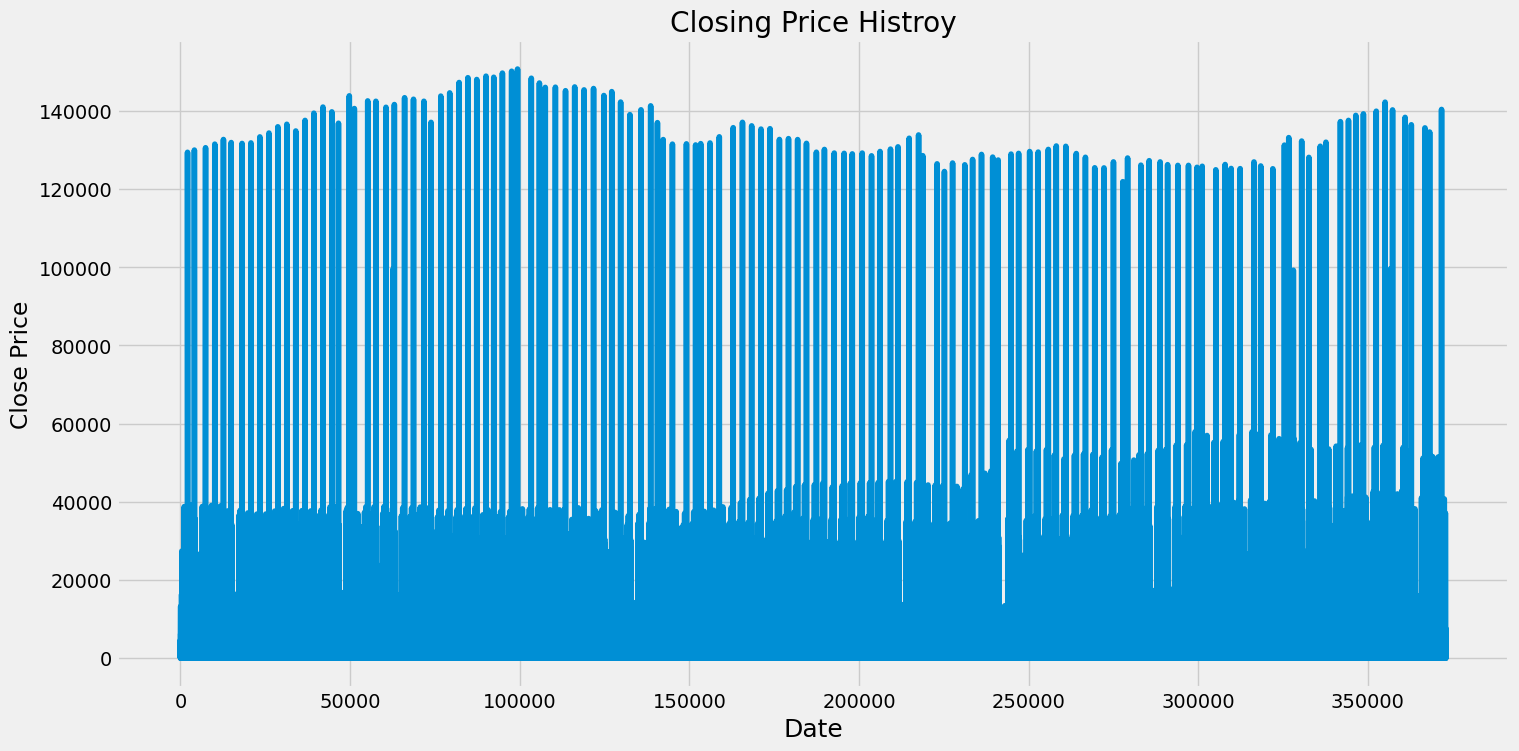

In [7]:
plt.figure(figsize = (16,8))
plt.title('Closing Price Histroy')
plt.plot(preprocessed_df['ClsPric'])
plt.xlabel('Date', fontsize = 18)
plt.ylabel('Close Price')
plt.show()